## General introduction

The first model (first model) for deep vision (pre-trained ResNet50) classifies skin lesions into seven classes from the HAM10000 dataset (10,015 dermatoscopic images). Preprocessing includes image resizing to 224x224, specific normalization, and augmentations (horizontal/vertical flips, 20° rotation, slight color variation). The dataset is highly unbalanced: for example, nevi (melanocytic nevi class) represent ~60% of the images, while some rare classes such as dermatofibroma or vascular lesions represent <2%. Currently, the author has rebalanced the training set by downsampling each class to a maximum of 450 images, which reduces the training set to ~2315 images (from 9013 initially). The model is trained on 22 epochs with Adam (lr=1e-3) without a scheduler, and all ResNet50 layers are fine-tuned (no weight freezing). Current results: On the test set (752 images), the model achieves ~65% overall accuracy.

Currently, the author has rebalanced the training set by downsampling each class to a maximum of 450 images, which reduces the training set to ~2315 images (from 9013 initially). The model is trained on 22 epochs with Adam (lr=1e-3) without a scheduler, and all ResNet50 layers are fine-tuned (no weight freezing). Current results: On the test set (752 images), the model achieves ~65% overall accuracy.

Performance varies greatly across classes: e.g., the algorithm detects moles well (F1 ~0.78) but struggles with melanoma (F1 ~0.42, although the recall is 74%). This suggests many false positives for melanoma (precision 30%) and, conversely, missed melanomas in favor of other classes. There is therefore significant room for improvement in accuracy, especially since the literature reports models reaching 83–85% accuracy with ResNet or EfficientNet on the same dataset, and up to ~90% with advanced techniques.

Below we propose an action plan to improve (1) model accuracy, (2) training speed, and (3) model compactness for deployment, by analyzing each aspect of the current code and suggesting concrete improvements.

## Importing data

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
surajghuwalewala_ham1000_segmentation_and_classification_path = kagglehub.dataset_download('surajghuwalewala/ham1000-segmentation-and-classification')

print('Data source import complete.')

Data source import complete.


## I. RESNET MODEL (First model)

In [ ]:
%matplotlib inline
# python libraties
import os, cv2,itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob
from PIL import Image
from random import randint

# pytorch libraries
import torch
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader,Dataset
from torchvision import models,transforms

# sklearn libraries
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

## Model: EfficientNet-B0 pre-trained via timm
import timm

# to make the results are reproducible
np.random.seed(10)
torch.manual_seed(10)
torch.cuda.manual_seed(10)

In [ ]:
DATA_PATH = surajghuwalewala_ham1000_segmentation_and_classification_path
print(os.listdir(DATA_PATH))

['GroundTruth.csv', 'images', 'masks']


In [ ]:
df=pd.read_csv(os.path.join(DATA_PATH,'GroundTruth.csv'))
print (df.head())
print (len(df))
print (df.columns)

          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0
10015
Index(['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC'], dtype='object')


In [ ]:
df['image']=df['image'].apply(lambda x: x+ '.jpg')
print (df.head())

              image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306.jpg  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307.jpg  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308.jpg  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309.jpg  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310.jpg  1.0  0.0  0.0    0.0  0.0  0.0   0.0


In [ ]:
list(df.columns[1:])

['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

In [ ]:
lesion_type_dict = {
    'NV': 'Melanocytic nevi',
    'MEL': 'Melanoma',
    'BKL': 'Benign keratosis like lesions',
    'BCC': 'Basal cell carcinoma',
    'AKIEC': 'Actinic keratoses',
    'VASC': 'Vascular lesions',
    'DF': 'Dermatofibroma'
}

labels = list(df.columns[1:])
label_list=[]
for i in range (len(df)):
    row= list(df.iloc[i])[1:]
    index=np.argmax(row)
    label=lesion_type_dict[labels[index]]
    label_list.append(label)
df['label']= label_list
df=df.drop(labels, axis=1)
df['label_idx'] = pd.Categorical(df['label']).codes
print(df.head())

              image             label  label_idx
0  ISIC_0024306.jpg  Melanocytic nevi          4
1  ISIC_0024307.jpg  Melanocytic nevi          4
2  ISIC_0024308.jpg  Melanocytic nevi          4
3  ISIC_0024309.jpg  Melanocytic nevi          4
4  ISIC_0024310.jpg          Melanoma          5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   image      10015 non-null  object
 1   label      10015 non-null  object
 2   label_idx  10015 non-null  int8  
dtypes: int8(1), object(2)
memory usage: 166.4+ KB


In [ ]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   image      10015 non-null  object
 1   label      10015 non-null  object
 2   label_idx  10015 non-null  int8  
dtypes: int8(1), object(2)
memory usage: 166.4+ KB


(450, 600, 3)


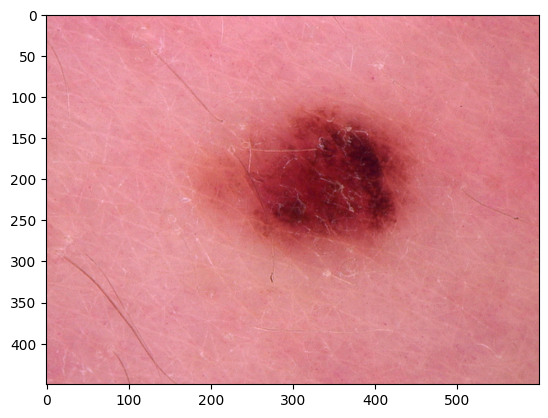

In [ ]:
images_path = os.path.join(DATA_PATH,'images')
image_files = os.listdir(images_path)
random_file = image_files[randint(0,len(image_files)-1)]
random_file = os.path.join(images_path, random_file)
img=plt.imread(random_file)
print (img.shape)
plt.imshow(img)

In [ ]:
train_split=.9 # set this to the percentof the data you want to use for training
valid_split=.025 # set this to the percent of the data you want to use for validation
# Note percent of data sed for test is 1-train_split-valid_split

valid_split=valid_split/(1-train_split)
train_test_split
train_df, val_test_df = train_test_split(df, train_size=train_split, random_state=62)
val_df, test_df = train_test_split(val_test_df, train_size=valid_split, random_state=62)
print('Data Len Train:', len(train_df), 'Val:', len(val_df), 'Test:', len(test_df))

Data Len Train: 9013 Val: 250 Test: 752


In [ ]:
print (train_df['label'].value_counts())

label
Melanocytic nevi                 6046
Melanoma                         1006
Benign keratosis like lesions     986
Basal cell carcinoma              460
Actinic keratoses                 286
Vascular lesions                  128
Dermatofibroma                    101
Name: count, dtype: int64


In [ ]:
max_size=450 # set maximum number of samples for each class
samples=[]
group=train_df.groupby('label')
for label in train_df['label'].unique():
    Lgroup=group.get_group(label)
    count=int(Lgroup['label'].value_counts())
    if count>=max_size:
        sample=Lgroup.sample(max_size, axis=0)
    else:
        sample=Lgroup.sample(frac=1, axis=0)
    samples.append(sample)
train_df=pd.concat(samples, axis=0).reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print(train_df['label'].value_counts())

label
Melanocytic nevi                 450
Benign keratosis like lesions    450
Basal cell carcinoma             450
Melanoma                         450
Actinic keratoses                286
Vascular lesions                 128
Dermatofibroma                   101
Name: count, dtype: int64


<ipython-input-14-09af6874c1b9>:6: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  count=int(Lgroup['label'].value_counts())
<ipython-input-14-09af6874c1b9>:6: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  count=int(Lgroup['label'].value_counts())
<ipython-input-14-09af6874c1b9>:6: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  count=int(Lgroup['label'].value_counts())
<ipython-input-14-09af6874c1b9>:6: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  count=int(Lgroup['label'].value_counts())
<ipython-input-14-09af6874c1b9>:6: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeErro

In [ ]:
def compute_img_mean_std(image_paths):
    """
        computing the mean and std of three channel on the whole dataset,
        first we should normalize the image from 0-255 to 0-1
    """

    img_h, img_w = 224, 224
    imgs = []
    means, stdevs = [], []

    for i in tqdm(range(len(image_paths))):
        img = cv2.imread(image_paths[i])
        img = cv2.resize(img, (img_h, img_w))
        imgs.append(img)

    imgs = np.stack(imgs, axis=3)
    print(imgs.shape)

    imgs = imgs.astype(np.float32) / 255.

    for i in range(3):
        pixels = imgs[:, :, i, :].ravel()  # resize to one row
        means.append(np.mean(pixels))
        stdevs.append(np.std(pixels))

    means.reverse()  # BGR --> RGB
    stdevs.reverse()

    print("normMean = {}".format(means))
    print("normStd = {}".format(stdevs))
    return means,stdevs

norm_mean = [0.76303685, 0.54564613, 0.570045]
norm_std = [0.14092818, 0.15261282, 0.16997021]
# image_paths = glob(os.path.join(DATA_PATH,'images','*.jpg'))
# norm_mean,norm_std = compute_img_mean_std(image_paths)

In [ ]:
# define the transformation of the train images.
train_transform = transforms.Compose([transforms.Resize((224,224)),transforms.RandomHorizontalFlip(),
                                      transforms.RandomVerticalFlip(),transforms.RandomRotation(20),
                                      transforms.ColorJitter(brightness=0.1, contrast=0.1, hue=0.1),
                                        transforms.ToTensor(), transforms.Normalize(norm_mean, norm_std)])
# define the transformation of the val and test images.
val_transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(),
                                    transforms.Normalize(norm_mean, norm_std)])

In [ ]:
# Define a pytorch dataloader for this dataset
class HAM10000(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        # Load data and get label
        X = Image.open(os.path.join(DATA_PATH, 'images', self.df['image'][index]))
        y = torch.tensor(int(self.df['label_idx'][index]))

        if self.transform:
            X = self.transform(X)

        return X, y

In [ ]:
BATCH_SIZE = 64
NUM_WORKERS = 2

# Define the training,val,test sets using the tables and using our defined transitions
train_set = HAM10000(train_df, transform=train_transform)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

val_set = HAM10000(val_df, transform=val_transform)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

test_set = HAM10000(test_df, transform=val_transform)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print('Data Len Train:', len(train_set), 'Val:', len(val_set), 'Test:', len(test_set))

Data Len Train: 2315 Val: 250 Test: 752


In [ ]:
class mySimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 53 * 53, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 6)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

print(mySimpleNet())

mySimpleNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=44944, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=6, bias=True)
)


In [ ]:
# feature_extract is a boolean that defines if we are finetuning or feature extracting.
# If feature_extract = False, the model is finetuned and all model parameters are updated.
# If feature_extract = True, only the last layer parameters are updated, the others remain fixed.
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

def initialize_model(model_name, num_classes, feature_extract, use_pretrained=True):
    # Initialize these variables which will be set in this if statement. Each of these
    #   variables is model specific.
    model_ft = None

    if model_name == "resnet":
        """ Resnet18, resnet34, resnet50, resnet101
        """
        model_ft = models.resnet50(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs, num_classes)


    elif model_name == "vgg":
        """ VGG11_bn
        """
        model_ft = models.vgg11_bn(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier[6].in_features
        model_ft.classifier[6] = nn.Linear(num_ftrs,num_classes)

    elif model_name == "densenet":
        """ Densenet121
        """
        model_ft = models.densenet121(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier.in_features
        model_ft.classifier = nn.Linear(num_ftrs, num_classes)

    elif model_name == "customnet":
        """ Our Custom CNN Model"""
        model_ft = mySimpleNet()
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.fc3.in_features
        model_ft.fc3 = nn.Linear(num_ftrs, num_classes)

    else:
        print("Invalid model name, exiting...")
        exit()
    return model_ft

In [ ]:
class AverageMeter(object):
    """Computes and stores the epochs average and current value in batches"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val):
        self.val = val
        self.sum += val
        self.count += 1
        self.avg = self.sum / self.count


def train(train_loader, model, criterion, optimizer, epoch):
    model.train()
    train_loss = AverageMeter()
    train_acc = AverageMeter()
    for i, data in enumerate(train_loader):
        images, labels = data
        N = images.size(0)
        # print('image shape:',images.size(0), 'label shape',labels.size(0))
        images = Variable(images).to(device)
        labels = Variable(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        prediction = outputs.max(1, keepdim=True)[1]
        train_acc.update(prediction.eq(labels.view_as(prediction)).sum().item()/N)
        train_loss.update(loss.item())
        if (i + 1) % 10 == 0:
            print('[epoch %d], [iter %d / %d], [train loss %.5f], [train acc %.5f]' % (
                epoch, i + 1, len(train_loader), train_loss.avg, train_acc.avg))
    return train_loss.avg, train_acc.avg

def validate(val_loader, model, criterion, optimizer, epoch):
    model.eval()
    val_loss = AverageMeter()
    val_acc = AverageMeter()
    with torch.no_grad():
        for i, data in enumerate(val_loader):
            images, labels = data
            N = images.size(0)
            images = Variable(images).to(device)
            labels = Variable(labels).to(device)

            outputs = model(images)
            prediction = outputs.max(1, keepdim=True)[1]

            val_acc.update(prediction.eq(labels.view_as(prediction)).sum().item()/N)

            val_loss.update(criterion(outputs, labels).item())

    print('------------------------------------------------------------')
    print('[epoch %d], [val loss %.5f], [val acc %.5f]' % (epoch, val_loss.avg, val_acc.avg))
    print('------------------------------------------------------------')
    return val_loss.avg, val_acc.avg

In [ ]:
# resnet,vgg,densenet,customnet
model_name = 'resnet'




num_classes = len(train_df['label'].unique())
feature_extract = False
# Initialize the model for this run
model_ft = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)
print(model_ft)
# Define the device:
device = torch.device('cuda:0') # gpu
# Put the model on the device:
model = model_ft.to(device)

In [ ]:
epoch_num = 22
learning_rate = 1e-3


best_val_acc = 0
total_loss_val, total_acc_val = [],[]
total_loss_train, total_acc_train = [],[]

# we use Adam optimizer, use cross entropy loss as our loss function
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss().to(device)

for epoch in range(1, epoch_num+1):
    loss_train, acc_train = train(train_loader, model, criterion, optimizer, epoch)
    total_loss_train.append(loss_train)
    total_acc_train.append(acc_train)
    loss_val, acc_val = validate(val_loader, model, criterion, optimizer, epoch)
    total_loss_val.append(loss_val)
    total_acc_val.append(acc_val)
    if acc_val > best_val_acc:
        best_val_acc = acc_val
        print('*****************************************************')
        print('best record: [epoch %d], [val loss %.5f], [val acc %.5f]' % (epoch, loss_val, acc_val))
        print('*****************************************************')

In [ ]:
fig = plt.figure(num = 2)
fig1 = fig.add_subplot(2,1,1)
fig2 = fig.add_subplot(2,1,2)
fig1.plot(total_loss_train, label = 'training loss')
fig1.plot(total_loss_val, label = 'validation loss')

fig2.plot(total_acc_train, label = 'training accuracy')
fig2.plot(total_acc_val, label = 'validation accuracy')
plt.legend()
plt.show()

In [ ]:
loss_test, acc_test = validate(test_loader, model, criterion, optimizer, 1)

In [ ]:
plot_labels = list(df[['label', 'label_idx']].drop_duplicates().sort_values(by='label_idx')['label'])
print({ind: val for ind,val in enumerate(plot_labels)})

In [ ]:
model.eval()
y_label = []
y_predict = []
with torch.no_grad():
    for i, data in enumerate(test_loader):
        images, labels = data
        N = images.size(0)
        images = Variable(images).to(device)
        outputs = model(images)
        prediction = outputs.max(1, keepdim=True)[1]
        y_label.extend(labels.cpu().numpy())
        y_predict.extend(np.squeeze(prediction.cpu().numpy().T))

# Generate a classification report
report = classification_report(y_label, y_predict, target_names=plot_labels)
print(report)

In [ ]:
# skin_cancer_model_upgrade.py

import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from torch.cuda.amp import autocast, GradScaler
import timm
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split # Import train_test_split here
import tensorflow as tf


# Configurations
BATCH_SIZE = 64
NUM_WORKERS = 4
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT_PROB = 0.5
PATIENCE = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(45),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset
import kagglehub
surajghuwalewala_ham1000_segmentation_and_classification_path = kagglehub.dataset_download('surajghuwalewala/ham1000-segmentation-and-classification')

DATA_PATH = surajghuwalewala_ham1000_segmentation_and_classification_path
df = pd.read_csv(os.path.join(DATA_PATH, 'GroundTruth.csv'))
df['image'] = df['image'].apply(lambda x: x + '.jpg')


lesion_type_dict = {
    'NV': 'Melanocytic nevi',
    'MEL': 'Melanoma',
    'BKL': 'Benign keratosis like lesions',
    'BCC': 'Basal cell carcinoma',
    'AKIEC': 'Actinic keratoses',
    'VASC': 'Vascular lesions',
    'DF': 'Dermatofibroma'
}

labels = list(df.columns[1:])
label_list = []
for i in range(len(df)):
    row = list(df.iloc[i])[1:]
    index = np.argmax(row)
    label = lesion_type_dict[labels[index]]
    label_list.append(label)
df['label'] = label_list
df = df.drop(labels, axis=1)
df['label_idx'] = pd.Categorical(df['label']).codes


# Define a custom dataset class
# Define a custom dataset class
class HAM10000(Dataset):
    def __init__(self, df, data_path, transform=None):
        self.df = df
        self.data_path = data_path
        self.transform = transform
        # Add this line to get unique labels
        self.classes = self.df['label'].unique()
        # Reset the index of the DataFrame
        self.df = self.df.reset_index(drop=True)  # Add this line

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        # Load data and get label
        X = Image.open(os.path.join(self.data_path, 'images', self.df['image'][index]))
        y = torch.tensor(int(self.df['label_idx'][index]))

        if self.transform:
            X = self.transform(X)

        return X, y


# Load dataset using the custom dataset class
train_df, val_df = train_test_split(df, train_size=0.8, random_state=62)  # Adjust train_size as needed
train_dataset = HAM10000(train_df, DATA_PATH, transform=train_transform)
val_dataset = HAM10000(val_df, DATA_PATH, transform=val_transform)
# Now you can use len(train_dataset.classes) to get the number of classes
num_classes = len(train_dataset.classes)


# Weighted sampling
# Get labels from the DataFrame directly
labels = train_dataset.df['label_idx'].tolist()  # Get labels directly from DataFrame
class_sample_count = np.array([len(np.where(np.array(labels) == t)[0]) for t in range(num_classes)])
weights = 1. / class_sample_count
samples_weight = np.array([weights[t] for t in labels])
samples_weight = torch.from_numpy(samples_weight)
sampler = WeightedRandomSampler(samples_weight.type('torch.DoubleTensor'), len(samples_weight), replacement=True)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Model
model = timm.create_model('efficientnet_b0', pretrained=True)
num_ftrs = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(DROPOUT_PROB),
    nn.Linear(num_ftrs, num_classes)
)
model = model.to(DEVICE)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)
scaler = GradScaler()

# Training/validation loop
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    model.train()
    running_loss, running_corrects = 0.0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    print(f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    val_loss /= len(val_dataset)
    val_acc = val_corrects.double() / len(val_dataset)
    scheduler.step(val_loss)

    print(f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, 'best_model.pth')
        print("Model saved!")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("Early stopping triggered")
            break

# Load best model
model.load_state_dict(best_model_wts)

# Optional: Quantize for deployment
model.eval()
model.cpu()
model.qconfig = torch.quantization.get_default_qconfig('fbgemm')
torch.quantization.prepare(model, inplace=True)
# Simulate calibration with validation loader
for inputs, _ in val_loader:
    model(inputs)
torch.quantization.convert(model, inplace=True)
torch.save(model.state_dict(), 'model_quantized.pth')



# II. EFFICIENTNET B0 MODEL (Second model)



### INTRODUCTION

### 1. New model

#### 1.1. Train and evaluate model

In [ ]:
# Reinstall the correct versions in a fresh environment for model = timm.create_model('efficientnet_b0', pretrained=True)
!pip install --upgrade --quiet timm huggingface_hub
import timm


In [5]:
# skin_cancer_classification.py

# !pip install -q huggingface_hub timm # <--- Install huggingface_hub here

import os, copy
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torch.cuda.amp import autocast, GradScaler
import timm
from sklearn.model_selection import train_test_split
import zipfile
from google.colab import files
from google.colab import drive
drive.mount('drive')
import tensorflow as tf

basefolder='drive/MyDrive/Deep Learning/' #Path to replace depending on the desired location to store your models
Mname='Best_model' # Your model number. Increment each time you change something and restart training.
model_dir=os.path.join(basefolder,Mname)
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(model_dir, "best-{epoch:05d}-{val_loss:.4f}.keras"),
        save_best_only=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(model_dir, "at-{epoch:05d}.keras"),
        save_best_only=False, verbose=1, mode='auto', save_freq=500)
]


# ---- CONFIGURATION ----
# Load dataset
import kagglehub
surajghuwalewala_ham1000_segmentation_and_classification_path = kagglehub.dataset_download('surajghuwalewala/ham1000-segmentation-and-classification')
DATA_PATH = surajghuwalewala_ham1000_segmentation_and_classification_path
# DATA_PATH      = '/mnt/data/ham10000'   # chemin vers le dossier contenant GroundTruth.csv et le dossier images/
BATCH_SIZE     = 64
NUM_WORKERS    = 4
NUM_EPOCHS     = 30 # Nombre d'époque
LEARNING_RATE  = 1e-3
WEIGHT_DECAY   = 1e-4
DROPOUT_PROB   = 0.5
PATIENCE       = 8
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- TRANSFORMATIONS ----
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(45),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.GaussianBlur(5, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ---- READING METADATA ----
# GroundTruth.csv contains the columns [image, NV, MEL, BKL, BCC, AKIEC, VASC, DF]
csv_path = os.path.join(DATA_PATH, 'GroundTruth.csv')
df = pd.read_csv(csv_path)
df['image'] = df['image'] + '.jpg'

# Dictionnaire pour noms lisibles (optionnel)
lesion_type = {
    'NV':    'Melanocytic nevi',
    'MEL':   'Melanoma',
    'BKL':   'Benign keratosis like lesions',
    'BCC':   'Basal cell carcinoma',
    'AKIEC': 'Actinic keratoses',
    'VASC':  'Vascular lesions',
    'DF':    'Dermatofibroma'
}

# Choice of class via argmax of probas columns
proba_cols = ['NV','MEL','BKL','BCC','AKIEC','VASC','DF']
labels = []
for _, row in df.iterrows():
    idx = row[proba_cols].values.astype(float).argmax()
    labels.append(proba_cols[idx])
df['label']     = labels
df['label_idx'] = pd.Categorical(df['label'], categories=proba_cols).codes

# Split train/val
train_df, val_df = train_test_split(df, train_size=0.8, random_state=42, stratify=df['label_idx'])

# ---- DATASET PERSONNALISÉ ----
class HAM10000(Dataset):
    def __init__(self, df, data_path, transform=None):
        self.df        = df.reset_index(drop=True)
        self.data_path = data_path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fname = self.df.loc[idx, 'image']
        img   = Image.open(os.path.join(self.data_path, 'images', fname)).convert('RGB')
        label = int(self.df.loc[idx, 'label_idx'])
        if self.transform:
            img = self.transform(img)
        return img, label

train_ds = HAM10000(train_df, DATA_PATH, transform=train_transform)
val_ds   = HAM10000(val_df,   DATA_PATH, transform=val_transform)
num_classes = len(proba_cols)

# ---- WEIGHTED SAMPLER POUR ÉQUILIBRAGE ----
counts = train_df['label_idx'].value_counts().sort_index().values
weights = 1.0 / counts
sample_weights = weights[train_df['label_idx'].values]
sampler = WeightedRandomSampler(
    weights  = torch.DoubleTensor(sample_weights),
    num_samples = len(sample_weights),
    replacement = True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# ---- MODEL (EfficientNet-B0) ----
model = timm.create_model('efficientnet_b0', pretrained=True)
in_f = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(DROPOUT_PROB),
    nn.Linear(in_f, num_classes)
)
model = model.to(DEVICE)

# ---- CRITERION, OPTIMIZER, SCHEDULER, MIXED PRECISION ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=3, verbose=True
)
scaler = GradScaler()

# ---- TRAINING LOOP & VALIDATION ----
best_acc   = 0.0
best_state = copy.deepcopy(model.state_dict())
no_improve = 0

##### For accuracy and loss curves
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

#### End

for epoch in range(1, NUM_EPOCHS+1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    # -- Train --
    model.train()
    running_loss = 0.0
    running_corr = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            out  = model(imgs)
            loss = criterion(out, lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        preds = out.argmax(dim=1)
        running_loss += float(loss)*imgs.size(0)
        running_corr += int((preds==lbls).sum())
    train_loss = running_loss/len(train_ds)
    train_acc  = running_corr/len(train_ds)
    print(f" Train  ▶ loss={train_loss:.4f}  acc={train_acc:.4f}")

    # -- Validation --
    model.eval()
    val_loss, val_corr = 0.0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, lbls)
            preds = out.argmax(dim=1)
            val_loss += float(loss)*imgs.size(0)
            val_corr += int((preds==lbls).sum())
    val_loss /= len(val_ds)
    val_acc  = val_corr/len(val_ds)
    print(f" Val    ▶ loss={val_loss:.4f}  acc={val_acc:.4f}")

    ##### Update for accuracy and loss curves
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Scheduler & checkpointing
    scheduler.step(val_loss)
    if val_acc > best_acc:
        best_acc   = val_acc
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, 'best_model.pth')

        print(" ► New Best Saved Model")
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(" ► Early stopping déclenché")
            break

# Load the best model
model.load_state_dict(best_state)

#####################################
# Step 1: Save the model if it is not already saved
best_model_path=os.path.join(model_dir, 'best_model.pth')
torch.save(best_state, best_model_path) # best_model.pth

# Étape 2 : Créer une archive zip
# with zipfile.ZipFile('best_model.zip', 'w') as zipf:
#    zipf.write('best_model.pth')

# Étape 3 : Télécharger le fichier zip
# files.download('best_model.zip')
#####################################

# ---- OPTION : QUANTIZATION POST-TRAINING ----
model.cpu().eval()
model.qconfig = torch.quantization.get_default_qconfig('fbgemm')
torch.quantization.prepare(model, inplace=True)
for imgs, _ in val_loader:     # calibration
    model(imgs)
torch.quantization.convert(model, inplace=True)
#####################################
# Step 1: Save the model if it is not already saved
best_model_path=os.path.join(model_dir, 'model_quantized_int8.pth')
torch.save(model.state_dict(), best_model_path) # best_model.pth
# torch.save(model.state_dict(), os.path.join(basefolder, Mname, 'model_quantized_int8.pth'))


# Étape 2 : Créer une archive zip
# with zipfile.ZipFile('model_quantized_int8.zip', 'w') as zipf:
#    zipf.write('model_quantized_int8.pth')

# Étape 3 : Télécharger le fichier zip
# files.download('model_quantized_int8.zip')
#####################################

print("\nQuantified model saved as model_quantized_int8.pth")


Drive already mounted at drive; to attempt to forcibly remount, call drive.mount("drive", force_remount=True).

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
<ipython-input-5-f4fece5574f5>:153: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
<ipython-input-5-f4fece5574f5>:179: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


 Train  ▶ loss=0.9243  acc=0.6639
 Val    ▶ loss=0.8459  acc=0.7089
 ► New Best Saved Model

Epoch 2/30
 Train  ▶ loss=0.5577  acc=0.7899
 Val    ▶ loss=0.9851  acc=0.6505

Epoch 3/30
 Train  ▶ loss=0.5236  acc=0.8099
 Val    ▶ loss=0.6270  acc=0.7753
 ► New Best Saved Model

Epoch 4/30
 Train  ▶ loss=0.4207  acc=0.8480
 Val    ▶ loss=0.7536  acc=0.7039

Epoch 5/30
 Train  ▶ loss=0.3795  acc=0.8578
 Val    ▶ loss=0.5923  acc=0.7783
 ► New Best Saved Model

Epoch 6/30
 Train  ▶ loss=0.3532  acc=0.8726
 Val    ▶ loss=0.7827  acc=0.6995

Epoch 7/30
 Train  ▶ loss=0.3448  acc=0.8701
 Val    ▶ loss=0.6656  acc=0.7664

Epoch 8/30
 Train  ▶ loss=0.3185  acc=0.8852
 Val    ▶ loss=0.5959  acc=0.7803
 ► New Best Saved Model

Epoch 9/30
 Train  ▶ loss=0.3120  acc=0.8847
 Val    ▶ loss=0.7282  acc=0.7414

Epoch 10/30
 Train  ▶ loss=0.2171  acc=0.9174
 Val    ▶ loss=0.5822  acc=0.7888
 ► New Best Saved Model

Epoch 11/30
 Train  ▶ loss=0.1699  acc=0.9355
 Val    ▶ loss=0.5424  acc=0.8028
 ► New Bes

/usr/local/lib/python3.11/dist-packages/torch/ao/quantization/observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(



Quantified model saved as model_quantized_int8.pth


#### 1.2. Learning curves (loss & accuracy)

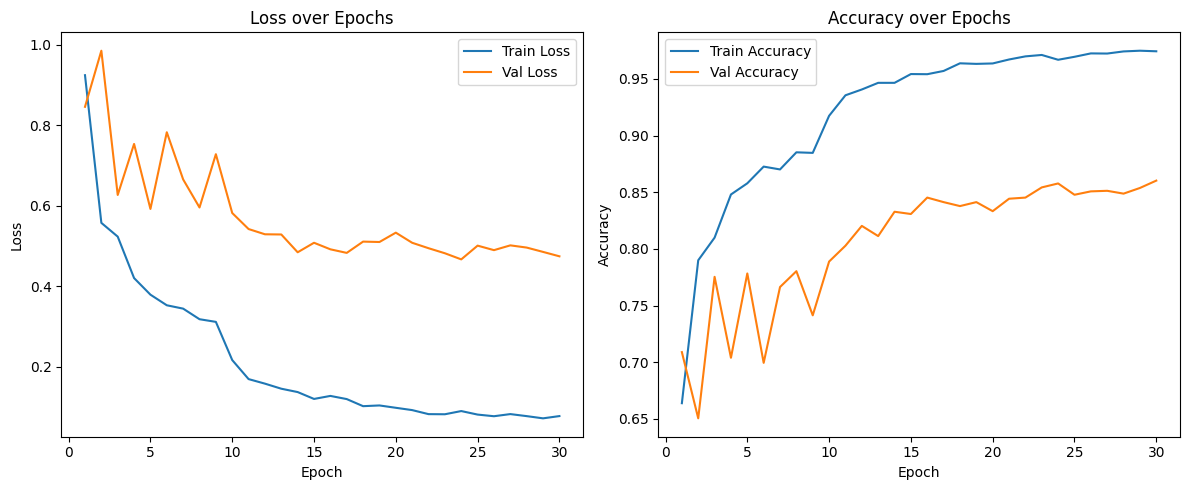

In [6]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss')
plt.plot(epochs_range, history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Accuracy')
plt.plot(epochs_range, history['val_acc'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


### 2. Load the model (with its best weights)

In [8]:
import timm
import torch
import torch.nn as nn

# === Recreate the model with the correct parameters ===
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=7) # True

# Replace the classifier (same as training)
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.classifier.in_features, 7)
)

# Load saved weights
model.load_state_dict(torch.load("/content/drive/MyDrive/Deep Learning/Best_model/best_model.pth", map_location='cpu'))
model.eval()


print("Model loaded successfully.")


Model loaded successfully.


### 3. Metric and confusion matrix

In [9]:
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())




EVALUATION OF THE FINAL MODEL
Accuracy : 0.8602096854717923
Precision: 0.8650415663544123
Recall   : 0.8602096854717923
F1 Score : 0.8618237270214038

Classification Report:
               precision    recall  f1-score   support

          NV       0.94      0.92      0.93      1341
         MEL       0.62      0.69      0.65       223
         BKL       0.75      0.75      0.75       220
         BCC       0.78      0.90      0.84       103
       AKIEC       0.73      0.66      0.69        65
        VASC       0.92      0.86      0.89        28
          DF       0.94      0.70      0.80        23

    accuracy                           0.86      2003
   macro avg       0.81      0.78      0.79      2003
weighted avg       0.87      0.86      0.86      2003



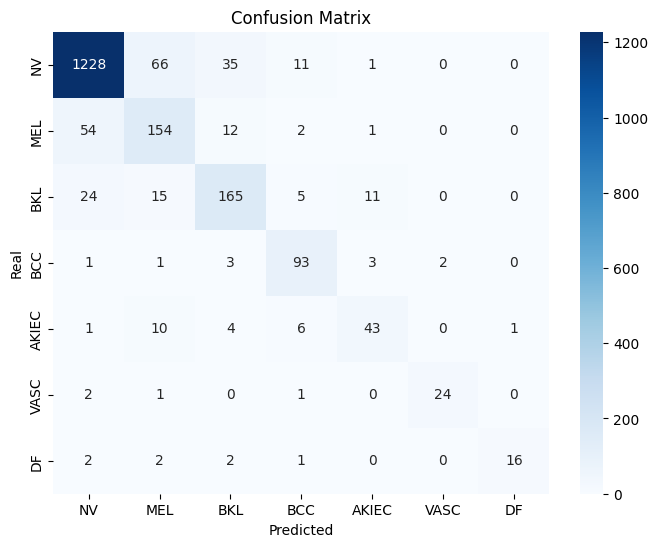

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# List of classes in index order
classes = ['NV', 'MEL', 'BKL', 'BCC', 'AKIEC', 'VASC', 'DF']

# Displaying metrics
print("\nEVALUATION OF THE FINAL MODEL")
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted', zero_division=0))
print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_true, y_pred, average='weighted'))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=classes, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()


### 4. Predict a single image

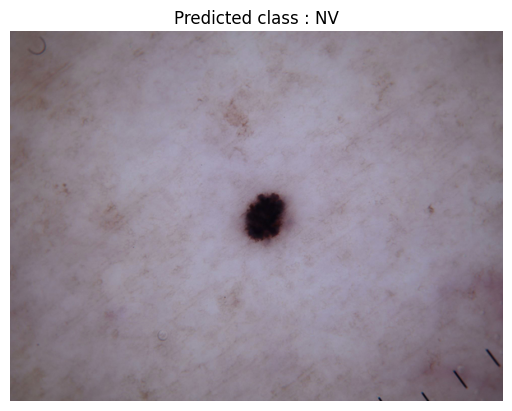

In [11]:
from PIL import Image
from torchvision import transforms
import os
import matplotlib.pyplot as plt
import kagglehub
surajghuwalewala_ham1000_segmentation_and_classification_path = kagglehub.dataset_download('surajghuwalewala/ham1000-segmentation-and-classification')

image_path = surajghuwalewala_ham1000_segmentation_and_classification_path
# Get a list of image files in the 'images' subdirectory
image_files = [f for f in os.listdir(os.path.join(image_path, 'images')) if f.endswith('.jpg')]
# Select a random image file
random_image_file = image_files[0]  # Or use random.choice(image_files) for a random image
# Construct the full path to the image file
image_path = os.path.join(image_path, 'images', random_image_file)


# Preprocessing identical to that used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

img = Image.open(image_path).convert("RGB")
img_tensor = transform(img).unsqueeze(0)

with torch.no_grad():
    output = model(img_tensor)
    pred_class = output.argmax(dim=1).item()

# List of classes
labels = ['NV', 'MEL', 'BKL', 'BCC', 'AKIEC', 'VASC', 'DF']
plt.imshow(img)
plt.title(f"Predicted class : {labels[pred_class]}")
plt.axis('off')  # Hide axes
plt.show()
# print("loss:", loss.item())



### 5. Predict multiple images

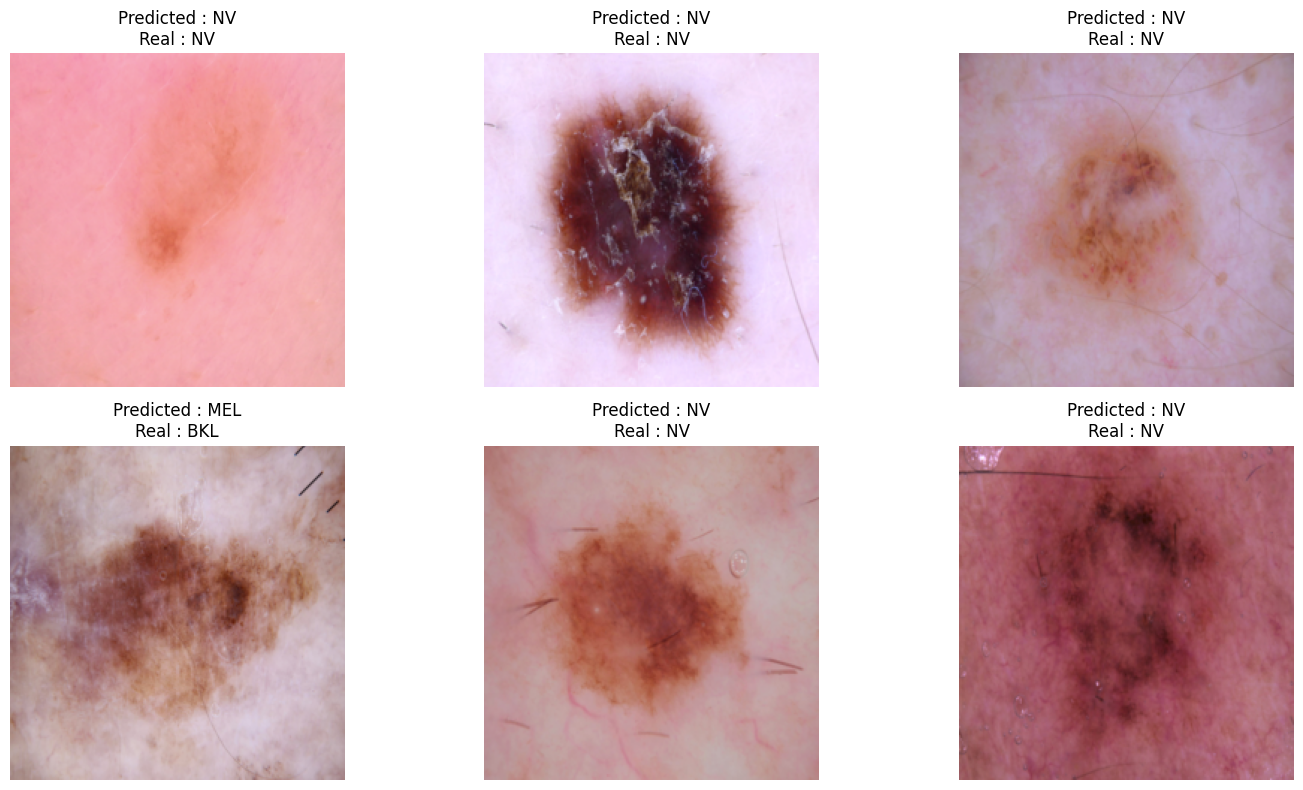

In [12]:
import matplotlib.pyplot as plt

model.to(DEVICE)
model.eval()
class_names = proba_cols

def imshow(img_tensor):
    img = img_tensor.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
count = 0
for img, label in val_loader:
    img = img[0].unsqueeze(0).to(DEVICE)
    label = label[0].item()
    with torch.no_grad():
        pred = model(img).argmax(dim=1).item()
    img_disp = imshow(img[0].cpu())
    axs[count//3, count%3].imshow(img_disp)
    axs[count//3, count%3].axis('off')
    axs[count//3, count%3].set_title(f"Predicted : {class_names[pred]}\nReal : {class_names[label]}")
    count += 1
    if count == 6:
        break

plt.tight_layout()
plt.show()


### Conclusion

The developed model achieves high classification performance (86% accuracy) and demonstrates robustness across multiple skin lesion categories. It shows strong potential for clinical decision support
systems, helping dermatologists in early and accurate skin cancer detection.